In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

In [17]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


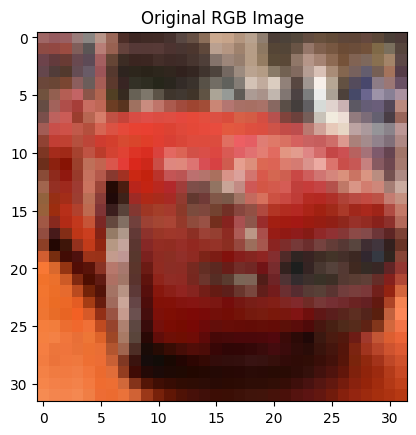

In [18]:
plt.imshow(X_train[5])
plt.title("Original RGB Image")
plt.show()

In [19]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [20]:
X_train_gray = tf.image.rgb_to_grayscale(X_train).numpy()
X_test_gray = tf.image.rgb_to_grayscale(X_test).numpy()

In [21]:
print(X_train_gray.shape)

(50000, 32, 32, 1)


In [22]:
X_train_gray = X_train_gray / 255.0
X_test_gray = X_test_gray / 255.0

In [23]:
print(X_train_gray.min(), X_train_gray.max())

0.0 0.99990004


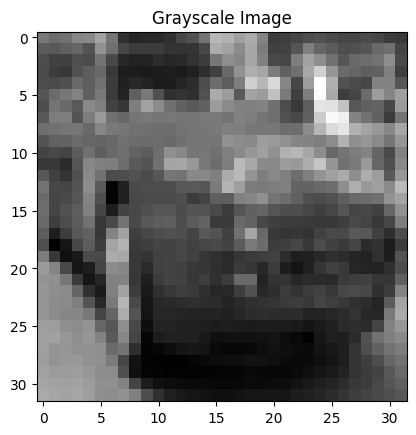

In [24]:
plt.imshow(X_train_gray[5], cmap='gray')
plt.title("Grayscale Image")
plt.show()

In [25]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)

(50000, 10)


In [26]:
X_train_aug, X_val_aug, y_train_aug, y_val_aug = train_test_split(
    X_train_gray,
    y_train,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train_aug.shape)
print(X_val_aug.shape)

(40000, 32, 32, 1)
(10000, 32, 32, 1)


In [28]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15
)

datagen.fit(X_train_aug)

In [29]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,1)))
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))


model.add(GlobalAveragePooling2D())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

c:\Users\vikas g\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

In [33]:
history = model.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=32),
    epochs=50,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=[early_stop, lr_scheduler]
)

c:\Users\vikas g\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 42ms/step - accuracy: 0.3456 - loss: 1.8328 - val_accuracy: 0.4020 - val_loss: 1.9742 - learning_rate: 0.0010
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 42ms/step - accuracy: 0.4791 - loss: 1.4666 - val_accuracy: 0.4273 - val_loss: 1.8257 - learning_rate: 0.0010
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.5259 - loss: 1.3494 - val_accuracy: 0.4215 - val_loss: 1.6972 - learning_rate: 0.0010
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 60s 48ms/step - accuracy: 0.5522 - loss: 1.2742 - val_accuracy: 0.4516 - val_loss: 1.8285 - learning_rate: 0.0010
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 43ms/step - accuracy: 0.5718 - loss: 1.2252 - val_accuracy: 0.5081 - val_loss: 1.5137 - learning_rate: 0.0010
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.5895 - loss: 1.1782 - val_accuracy: 0.5722 - val_loss: 1.3479 - learning_rate: 0.0010
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accura

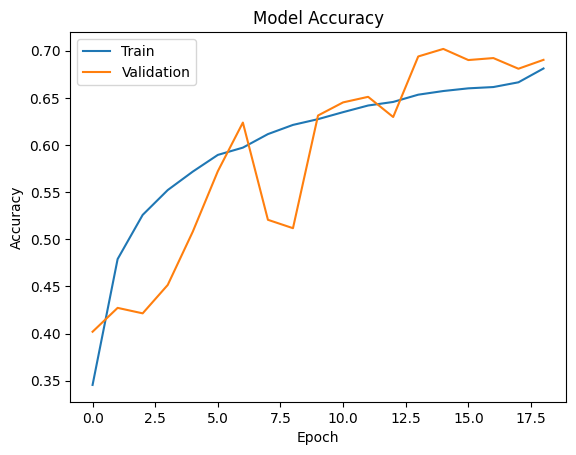

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

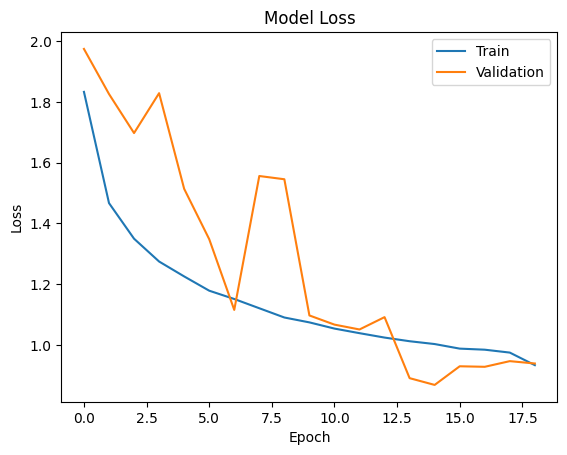

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

In [48]:
test_loss, test_acc =model.evaluate(X_test_gray, y_test)

print("Test Accuracy:", test_acc)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6929 - loss: 0.8900
Test Accuracy: 0.6929000020027161
Test loss: 0.8900019526481628


In [36]:
y_pred = model.predict(X_test_gray)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [37]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

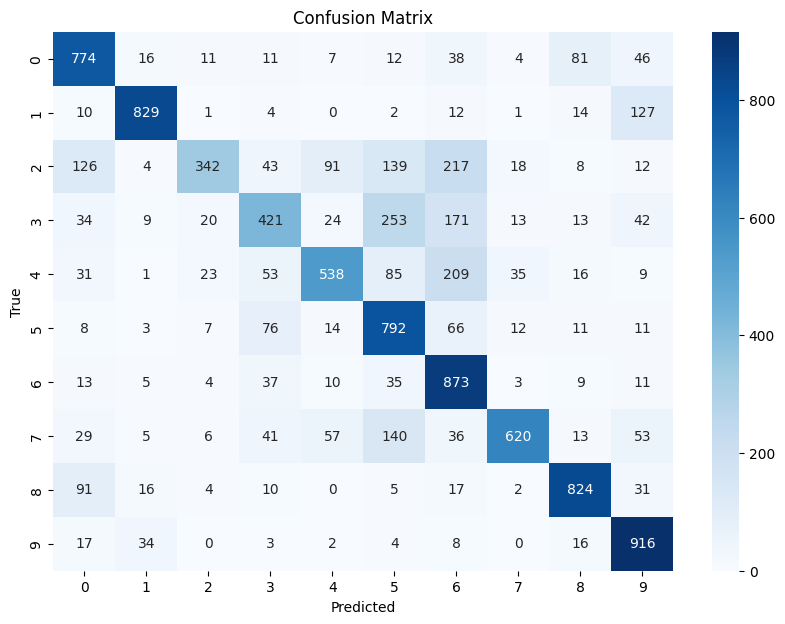

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.68      0.77      0.73      1000
           1       0.90      0.83      0.86      1000
           2       0.82      0.34      0.48      1000
           3       0.60      0.42      0.50      1000
           4       0.72      0.54      0.62      1000
           5       0.54      0.79      0.64      1000
           6       0.53      0.87      0.66      1000
           7       0.88      0.62      0.73      1000
           8       0.82      0.82      0.82      1000
           9       0.73      0.92      0.81      1000

    accuracy                           0.69     10000
   macro avg       0.72      0.69      0.68     10000
weighted avg       0.72      0.69      0.68     10000

